In [1]:
from itertools import combinations
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
import sys
sys.path.append("../")
sys.path.append("../src")
from difficulty.metrics.precomputed import load_memorization
from plots import data_utils
from plots.data_utils import get_score_metadata, get_score_key, plot_corr_matrix
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

DATA_ROOT = Path("../outputs/vit/")
DATASETS = [
    ("cifar10", "CIFAR-10"),
    ("cifar100", "CIFAR-100"),
    ("imagenet", "ImageNet"),
]
ARCHITECTURES = {
    "clip": "CLIP",
    "mammut": "MaMMUT",
}
PRETRAIN_DATA = {
    "datacomp_1b": "DataComp",
    "dfn_2b": "DFN",
    "relaion2b-en": "Re-LAION",
}
FIGURE_ROOT = Path("../outputs/plots/vit/")
FIGURE_ROOT.mkdir(exist_ok=True, parents=True)


def get_model_info(model_path):
    key = model_path.split("_globalbs")[0]
    method, size, samples_seen = key.split("_")[:3]
    pretrain = "_".join(key.split("_")[3:])
    return {
        "Model Architecture": ARCHITECTURES[method],
        "Model Size": size,
        "Pretrain Dataset": PRETRAIN_DATA[pretrain],
        "Pretrain Samples": samples_seen,
        "model_key": key,
    }


def get_score_df(model_df):
    score_df = []
    for dataset, dataset_name in DATASETS:
        for _, row in model_df.iterrows():
            model_path = row["path"]
            for score_file in (DATA_ROOT / dataset / model_path).rglob("*/*.npz"):
                key = get_score_key(score_file)
                if key is None:
                    continue
                metadata = get_score_metadata(score_file, "")
                metadata["Method"] = "One Step"
                if metadata["Epoch"] == row["early_epoch"]:
                    metadata["Training Time"] = "early"
                    metadata["Full Name"] = metadata["Short Name"] + " (Early)"
                elif metadata["Epoch"] == row["epoch"]:
                    metadata["Training Time"] = "late"
                    metadata["Full Name"] = metadata["Short Name"] + " (Late)"
                else:
                    raise ValueError
                score_df.append({
                    "Dataset": dataset_name,
                    **metadata,
                    **{k: v for k, v in row.items()},
                })
    return pd.DataFrame(score_df)


def get_score(score_row, invert=False):
    score = np.load(score_row["Path"])["arr_0"]
    if invert and score_row["key"] in data_utils.INVERSE:
        score = -1 * score
    return score


def get_scores(score_df, invert=False):
    return np.stack([get_score(row, invert=invert) for _, row in score_df.iterrows()], axis=0)


def corr_matrix_from_df(df, idx_row_A, idx_row_B, A_order=None, B_order=None, corr_row="Correlation", symmetric=False):
    idx_a = A_order if A_order is not None else sorted(df[idx_row_A].unique())
    idx_b = B_order if B_order is not None else sorted(df[idx_row_B].unique())
    m = len(A_order)
    n = len(B_order)
    if symmetric:
        m = max(n, m)
        n = m
    corr = np.full([m, n], np.nan)
    for i, a in enumerate(idx_a):
        for j, b in enumerate(idx_b):
            results = df[(df[idx_row_A] == a) & (df[idx_row_B] == b)]
            if len(results) > 0:
                corr[i, j] = np.mean(np.stack(results[corr_row]))
                if symmetric:
                    corr[j, i] = corr[i, j]
    return corr

/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_df = pd.read_csv("../vit/selected_models.csv")
m_df = []
for _, row in model_df.iterrows():
    path = row["full_name"]
    m_df.append({
        "path": path,
        **get_model_info(path),
        **{k: row[k] for k in ["full_name", "samples_seen", "global_batch_size", "lr", "warmup", "model_mparams", "model_image_mparams", "model_text_mparams", "acc1", "acc5", "mean_per_class_recall", "epoch", "early_epoch"]},
    })
model_df = pd.DataFrame(m_df)

score_df = get_score_df(model_df)
score_df

,Dataset,Path,Replicate,Epoch,Method,Short Name,Full Name,Type,key,Training Time,...,lr,warmup,model_mparams,model_image_mparams,model_text_mparams,acc1,acc5,mean_per_class_recall,epoch,early_epoch
0,CIFAR-10,../outputs/vit/cifar10/clip_ViT-M-32_s1.28B_da...,None,20,One Step,Accuracy,Accuracy (Late),,acc,late,...,0.0015,10000,103.12,39.69,63.43,0.57280,0.83396,0.57286,20,2
1,CIFAR-10,../outputs/vit/cifar10/clip_ViT-M-32_s1.28B_da...,None,2,One Step,Accuracy,Accuracy (Early),,acc,early,...,0.0015,10000,103.12,39.69,63.43,0.57280,0.83396,0.57286,20,2
2,CIFAR-10,../outputs/vit/cifar10/clip_ViT-M-32_s1.28B_da...,None,20,One Step,Confidence,Confidence (Late),,conf,late,...,0.0015,10000,103.12,39.69,63.43,0.57280,0.83396,0.57286,20,2
3,CIFAR-10,../outputs/vit/cifar10/clip_ViT-M-32_s1.28B_da...,None,2,One Step,Confidence,Confidence (Early),,conf,early,...,0.0015,10000,103.12,39.69,63.43,0.57280,0.83396,0.57286,20,2
4,CIFAR-10,../outputs/vit/cifar10/clip_ViT-M-32_s1.28B_da...,None,20,One Step,EL2N,EL2N (Late),,el2n,late,...,0.0015,10000,103.12,39.69,63.43,0.57280,0.83396,0.57286,20,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11041,ImageNet,../outputs/vit/imagenet/mammut_ViT-S-32_s640M_...,None,2,One Step,Max Confidence,Max Confidence (Early),,maxconf,early,...,0.0020,6000,85.62,22.64,62.83,0.53894,0.81586,0.53880,25,2
11042,ImageNet,../outputs/vit/imagenet/mammut_ViT-S-32_s640M_...,None,25,One Step,Supervised Prototypes,Supervised Prototypes (Late),,proto,late,...,0.0020,6000,85.62,22.64,62.83,0.53894,0.81586,0.53880,25,2
11043,ImageNet,../outputs/vit/imagenet/mammut_ViT-S-32_s640M_...,None,2,One Step,Supervised Prototypes,Supervised Prototypes (Early),,proto,early,...,0.0020,6000,85.62,22.64,62.83,0.53894,0.81586,0.53880,25,2
11044,ImageNet,../outputs/vit/imagenet/mammut_ViT-S-32_s640M_...,None,25,One Step,Self-Supervised Prototypes,Self-Supervised Prototypes (Late),,selfproto,late,...,0.0020,6000,85.62,22.64,62.83,0.53894,0.81586,0.53880,25,2


CIFAR-10
Saving figure to ../outputs/plots/vit/CIFAR-10_early_late_corr.pdf


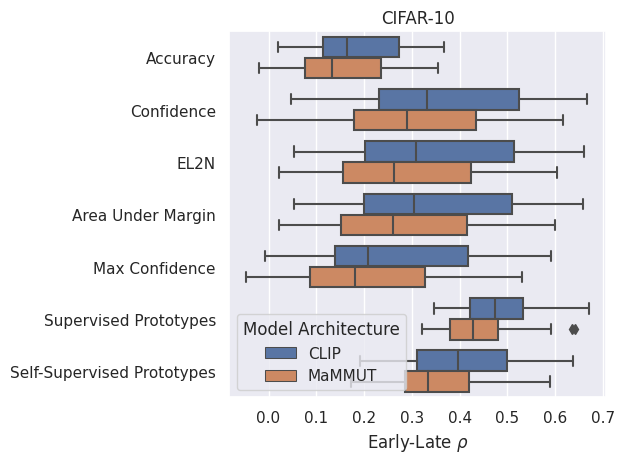

CIFAR-100
Saving figure to ../outputs/plots/vit/CIFAR-100_early_late_corr.pdf


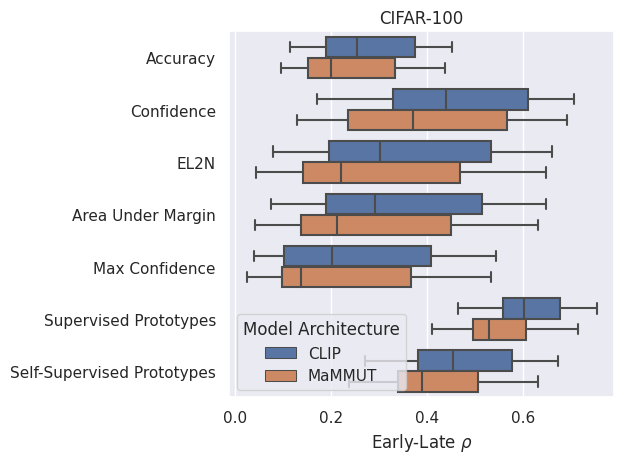

ImageNet
Saving figure to ../outputs/plots/vit/ImageNet_early_late_corr.pdf


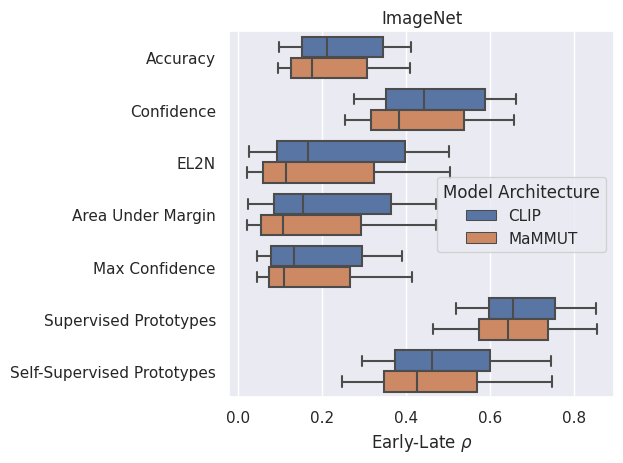

<Figure size 640x480 with 0 Axes>

In [16]:
# per-run early vs late correlations for each score, dataset, pretrain dataset, clip/mammut, model size
def compute_early_late_correlations(df):
    results = []
    for keys, sub_df in tqdm(df.groupby(["key", "full_name"])):
        if len(sub_df) != 2:
            print(f"Skipping {keys}")
            print(sub_df)
            break
            continue
        row_a = sub_df.iloc[0]
        score_a = get_score(row_a)
        row_b = sub_df.iloc[1]
        score_b = get_score(row_b)
        results.append({
            **{k: v for k, v in row_a.items()},
            "Correlation": spearmanr(score_a, score_b)[0],
        })
    return pd.DataFrame(results)


for dataset, sub_df in score_df.groupby("Dataset"):
    print(dataset)
    early_late_file = FIGURE_ROOT / f"early_late_corr_{dataset}.csv"
    if not early_late_file.exists():
        early_late_corr_df = compute_early_late_correlations(sub_df)
        early_late_corr_df.to_csv(early_late_file)
    early_late_corr_df = pd.read_csv(early_late_file, index_col=None)
    ax = sns.boxplot(data=early_late_corr_df, x="Correlation", y="Short Name", hue="Model Architecture")
    ax.set_title(dataset)
    ax.set_ylabel("")
    ax.set_xlabel("Early-Late $\\rho$")
    data_utils.save_fig(FIGURE_ROOT, "early_late_corr", dataset)

# for arch, sub_df in early_late_corr_df.groupby(["Model Architecture"]):
#     sub_df["order"] = sub_df.apply(lambda row: ["s300M", "s640M", "s1.28B", "s3B"].index(row["Pretrain Samples"]), axis=1)
#     sub_df = sub_df.sort_values(by="order")
#     plt.show()


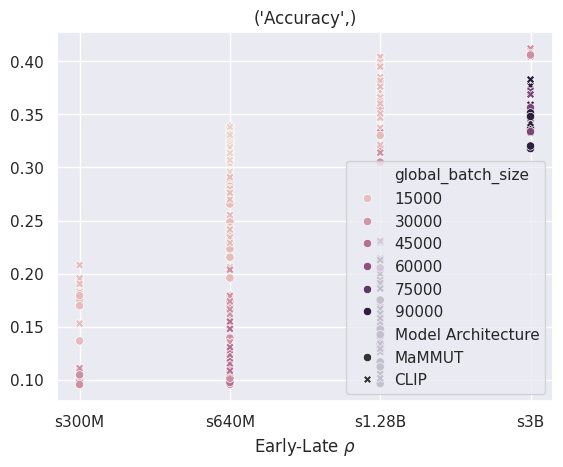

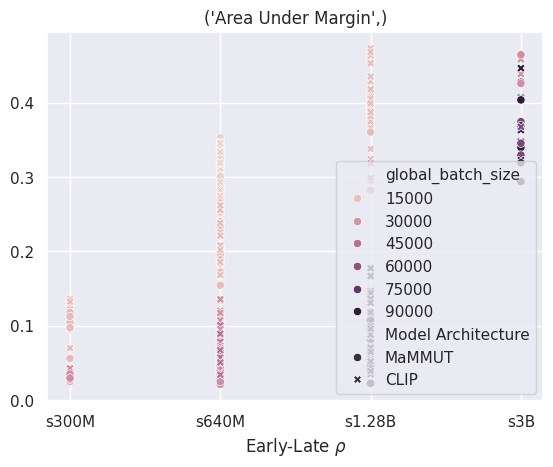

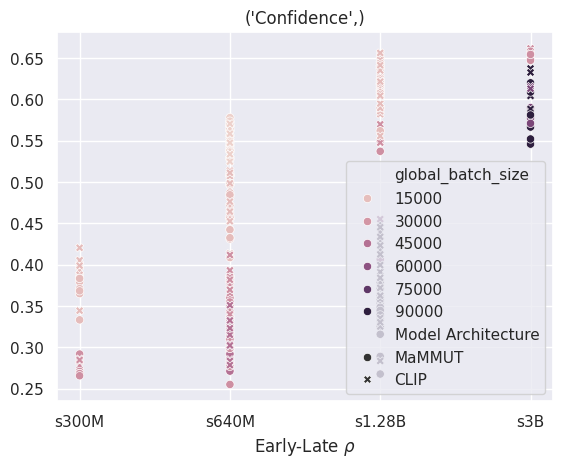

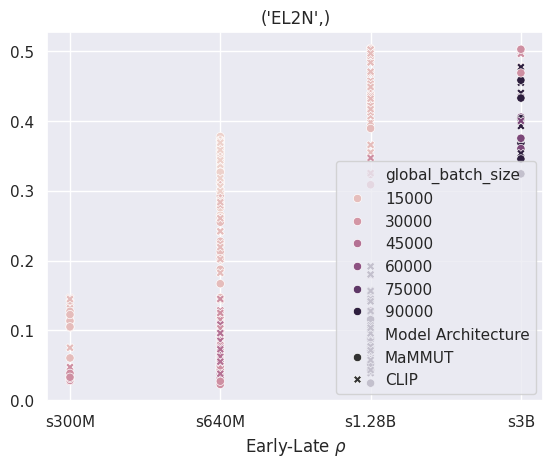

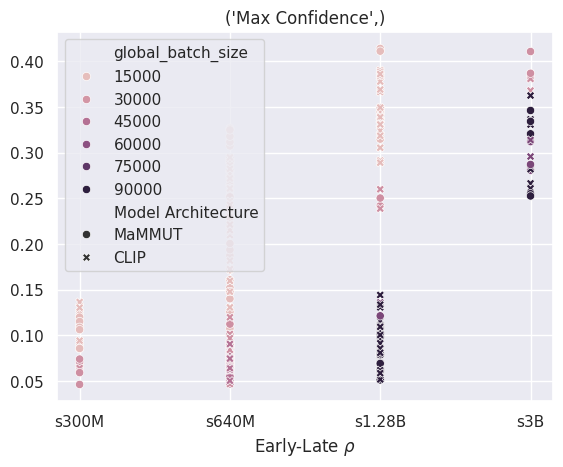

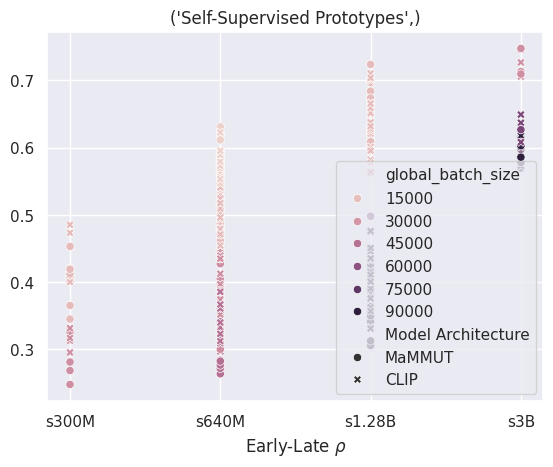

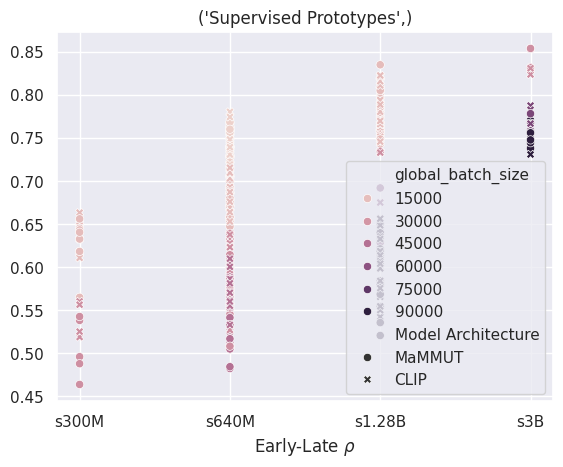

In [178]:
for (score), sub_df in early_late_corr_df.groupby(["Short Name"]):
    sub_df["order"] = sub_df.apply(lambda row: ["s300M", "s640M", "s1.28B", "s3B"].index(row["Pretrain Samples"]), axis=1)
    sub_df = sub_df.sort_values(by="order")
    # ax = sns.boxplot(data=sub_df, y="Correlation", x="Short Name", hue="model_text_mparams")
    ax = sns.scatterplot(data=sub_df, y="Correlation", hue="global_batch_size", x="Pretrain Samples", style="Model Architecture")
    ax.set_title(f"{score}")
    ax.set_ylabel("")
    ax.set_xlabel("Early-Late $\\rho$")
    plt.show()

In [13]:
sub_df

,Unnamed: 0,Unnamed: 0.1,Dataset,Path,Replicate,Epoch,Method,Short Name,Full Name,Type,...,model_mparams,model_image_mparams,model_text_mparams,acc1,acc5,mean_per_class_recall,epoch,early_epoch,Correlation,order
1810,1810,1810,ImageNet,../outputs/vit/imagenet/mammut_ViT-S-16_s640M_...,NaN,25,One Step,Self-Supervised Prototypes,Self-Supervised Prototypes (Late),NaN,...,84.79,21.81,62.83,0.50004,0.78428,0.50006,25,2,0.365073,1
1548,1548,1548,ImageNet,../outputs/vit/imagenet/mammut_ViT-S-16_s640M_...,NaN,25,One Step,Supervised Prototypes,Supervised Prototypes (Late),NaN,...,84.79,21.81,62.83,0.50004,0.78428,0.50006,25,2,0.586498,1
1286,1286,1286,ImageNet,../outputs/vit/imagenet/mammut_ViT-S-16_s640M_...,NaN,25,One Step,Max Confidence,Max Confidence (Late),NaN,...,84.79,21.81,62.83,0.50004,0.78428,0.50006,25,2,0.091078,1
1024,1024,1024,ImageNet,../outputs/vit/imagenet/mammut_ViT-S-16_s640M_...,NaN,25,One Step,Area Under Margin,Area Under Margin (Late),NaN,...,84.79,21.81,62.83,0.50004,0.78428,0.50006,25,2,0.090006,1
238,238,238,ImageNet,../outputs/vit/imagenet/mammut_ViT-S-16_s640M_...,NaN,25,One Step,Accuracy,Accuracy (Late),NaN,...,84.79,21.81,62.83,0.50004,0.78428,0.50006,25,2,0.172809,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387,387,387,ImageNet,../outputs/vit/imagenet/clip_ViT-S-32_s3B_rela...,NaN,48,One Step,Confidence,Confidence (Late),NaN,...,63.09,22.64,40.44,0.51520,0.78786,0.51506,48,5,0.584335,3
386,386,386,ImageNet,../outputs/vit/imagenet/clip_ViT-S-32_s3B_rela...,NaN,48,One Step,Confidence,Confidence (Late),NaN,...,63.09,22.64,40.44,0.51706,0.78918,0.51694,48,5,0.612947,3
385,385,385,ImageNet,../outputs/vit/imagenet/clip_ViT-S-32_s3B_rela...,NaN,48,One Step,Confidence,Confidence (Late),NaN,...,63.09,22.64,40.44,0.51852,0.79384,0.51802,48,5,0.661611,3
993,993,993,ImageNet,../outputs/vit/imagenet/mammut_ViT-S-16_s3B_re...,NaN,48,One Step,Area Under Margin,Area Under Margin (Late),NaN,...,84.79,21.81,62.83,0.57580,0.84098,0.57564,48,5,0.318965,3


CIFAR-10 early 1841
Saving figure to ../outputs/plots/vit/CIFAR-10_ind_ind_corr_early_selected.pdf


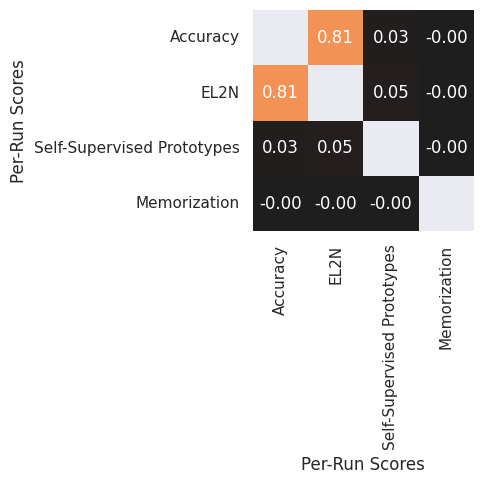

Saving figure to ../outputs/plots/vit/CIFAR-10_ind_ind_corr_early.pdf


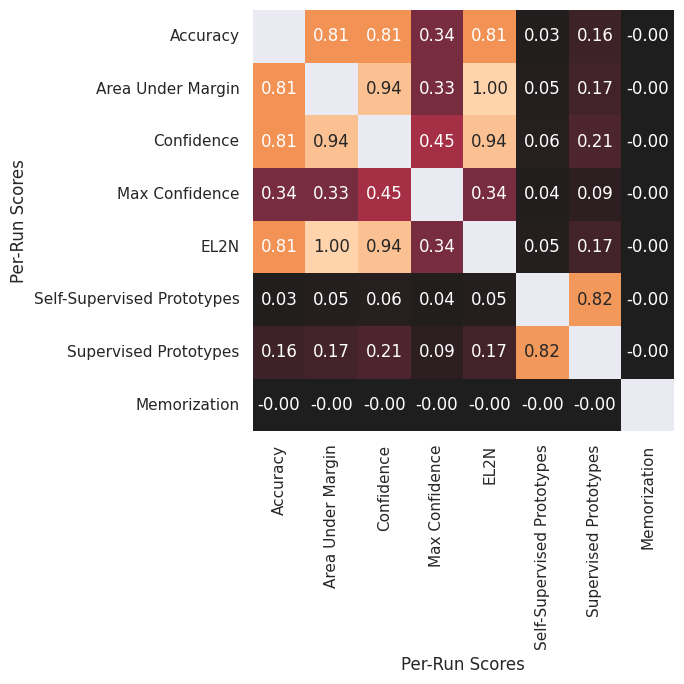

CIFAR-10 late 1841
Saving figure to ../outputs/plots/vit/CIFAR-10_ind_ind_corr_late_selected.pdf


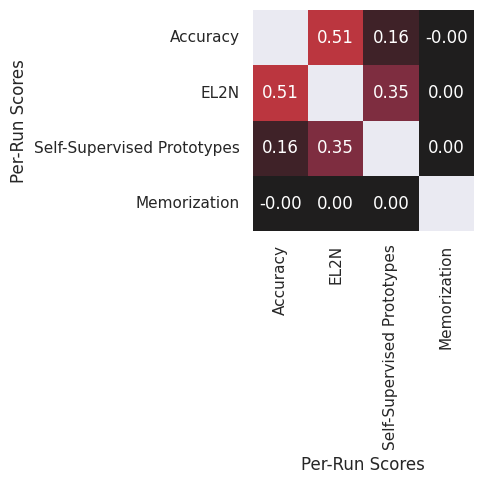

Saving figure to ../outputs/plots/vit/CIFAR-10_ind_ind_corr_late.pdf


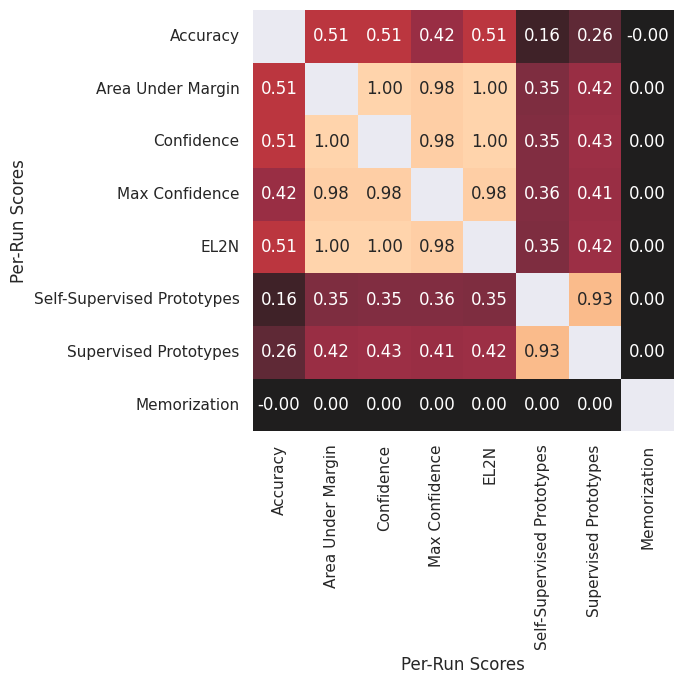

CIFAR-100 early 1841
Saving figure to ../outputs/plots/vit/CIFAR-100_ind_ind_corr_early_selected.pdf


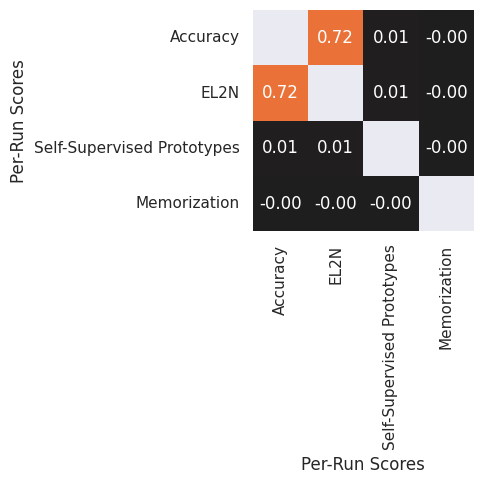

Saving figure to ../outputs/plots/vit/CIFAR-100_ind_ind_corr_early.pdf


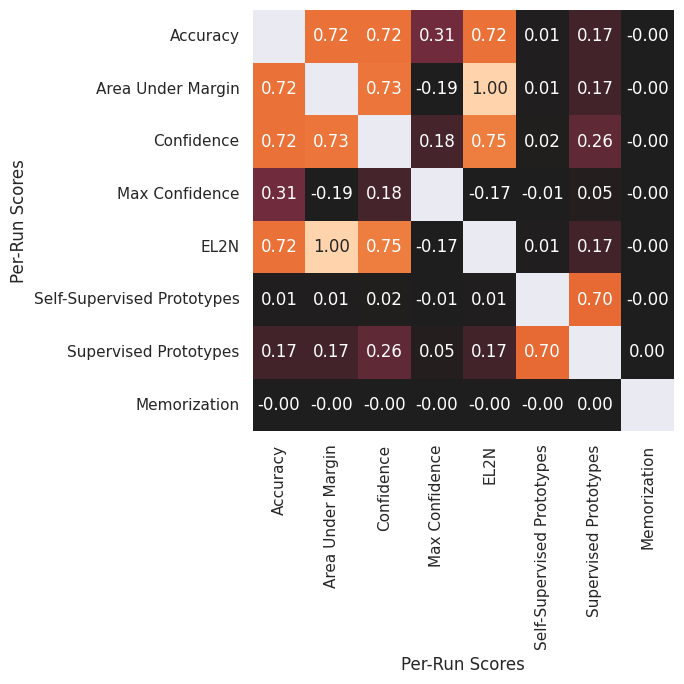

CIFAR-100 late 1841
Saving figure to ../outputs/plots/vit/CIFAR-100_ind_ind_corr_late_selected.pdf


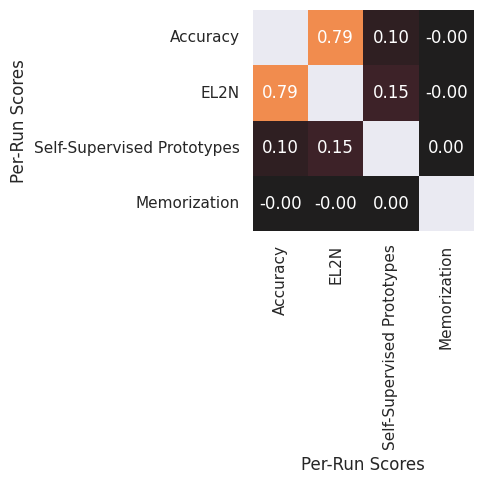

Saving figure to ../outputs/plots/vit/CIFAR-100_ind_ind_corr_late.pdf


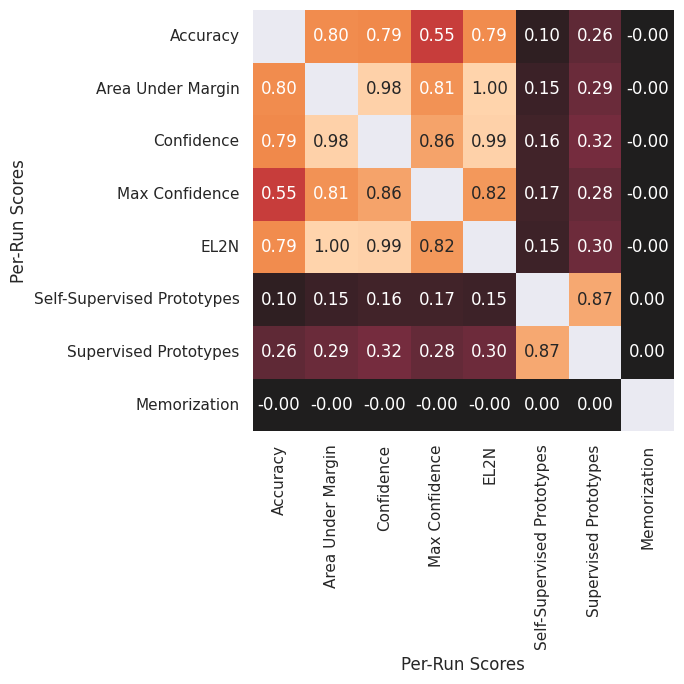

ImageNet early 1841
Saving figure to ../outputs/plots/vit/ImageNet_ind_ind_corr_early_selected.pdf


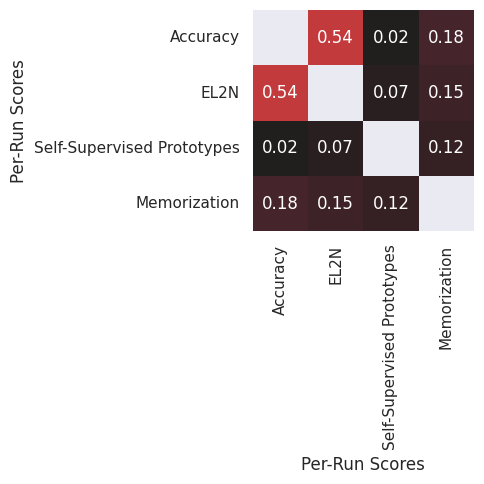

Saving figure to ../outputs/plots/vit/ImageNet_ind_ind_corr_early.pdf


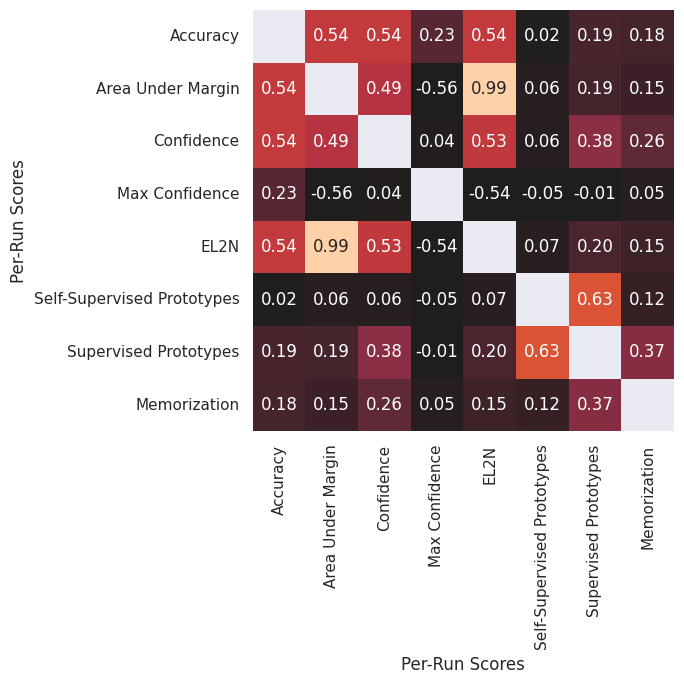

ImageNet late 1841
Saving figure to ../outputs/plots/vit/ImageNet_ind_ind_corr_late_selected.pdf


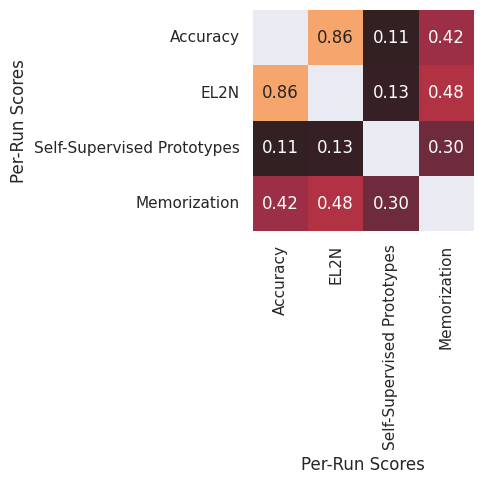

Saving figure to ../outputs/plots/vit/ImageNet_ind_ind_corr_late.pdf


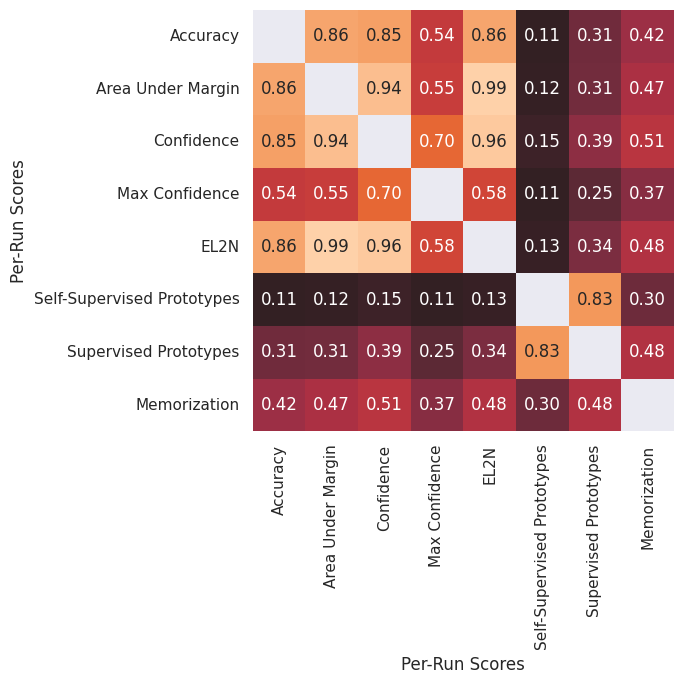

<Figure size 640x480 with 0 Axes>

In [19]:
# per-run score correlations

def load_imagenet_memorization_score():
    memorization_score_file = "../src/difficulty/precomputed/feldman-zhang-influence-memorization/imagenet_index.npz"
    torchvision_data_order = "../src/difficulty/precomputed/imagenet_tr_labels.npz"
    arrays = np.load(memorization_score_file, allow_pickle=True)
    # reindex to torchvision data order (sorted by image filename)
    sort_idx = np.argsort(arrays["tr_filenames"])
    ref_labels = np.load(torchvision_data_order)["tr_labels"]
    assert np.all(arrays["tr_labels"][sort_idx] == ref_labels)
    return arrays["tr_mem"][sort_idx]

def compute_score_correlations(df, dataset):
    memorization_score = load_memorization(dataset)
    results = []
    for _, sub_df in tqdm(df.groupby(["full_name"])):
        for i in range(len(sub_df)):
            for j in range(i+1, len(sub_df) + 1):
                row_a = sub_df.iloc[i]
                score_a = get_score(row_a, invert=True)
                if j == len(sub_df):
                    score_b = memorization_score
                    score_b_name = "Memorization"
                else:
                    row_b = sub_df.iloc[j]
                    score_b = get_score(row_b, invert=True)
                    score_b_name = row_b["Short Name"]
                results.append({
                    **{k: v for k, v in row_a.items()},
                    "Score A": row_a["Short Name"],
                    "Score B": score_b_name,
                    "Correlation": spearmanr(score_a, score_b)[0],
                })
    return pd.DataFrame(results)


SCORE_ORDER = ["acc", "conf", "maxconf", "el2n", "selfproto", "proto", "mem"]
SCORE_ORDER = ["Accuracy", "Area Under Margin", "Confidence", "Max Confidence", "EL2N", "Self-Supervised Prototypes", "Supervised Prototypes", "Memorization"]
MAIN_TEXT_SCORES = ["Accuracy", "EL2N", "Self-Supervised Prototypes", "Memorization"]
INVERTED = {"Accuracy", "Area Under Margin", "Confidence", "Max Confidence"}
score_order_idx = {k: i for i, k in enumerate(SCORE_ORDER)}

for (dataset, time,), sub_df in score_df.groupby(["Dataset", "Training Time"]):
    print(dataset, time, len(sub_df))
    corr_file = FIGURE_ROOT / f"score_corr_{dataset}_{time}.csv"
    if not corr_file.exists():
        dataset_key_lookup = {v: k for k, v in DATASETS}
        corr_df = compute_score_correlations(sub_df, dataset_key_lookup[dataset])
        corr_df.to_csv(corr_file)
    corr_df = pd.read_csv(corr_file)

    corr_matrix = corr_matrix_from_df(corr_df, "Score A", "Score B", A_order=MAIN_TEXT_SCORES, B_order=MAIN_TEXT_SCORES, symmetric=True)
    plot_corr_matrix(corr_matrix, "", "Per-Run Scores", MAIN_TEXT_SCORES)
    data_utils.save_fig(FIGURE_ROOT, f"ind_ind_corr_{time}_selected", dataset, figsize=(5, 5))

    corr_matrix = corr_matrix_from_df(corr_df, "Score A", "Score B", A_order=SCORE_ORDER, B_order=SCORE_ORDER, symmetric=True)
    plot_corr_matrix(corr_matrix, "", "Per-Run Scores", SCORE_ORDER)
    data_utils.save_fig(FIGURE_ROOT, f"ind_ind_corr_{time}", dataset, figsize=(7, 7))

CIFAR-10 el2n 263
Saving figure to ../outputs/plots/vit/CIFAR-10_el2n_corr.pdf


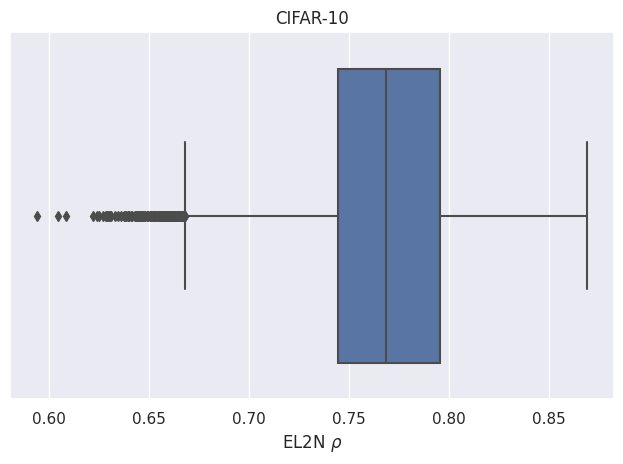

CIFAR-10 selfproto 263
Saving figure to ../outputs/plots/vit/CIFAR-10_selfproto_corr.pdf


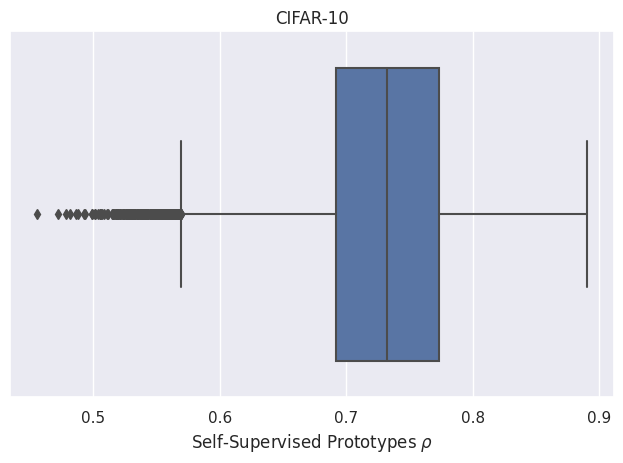

CIFAR-100 el2n 263
Saving figure to ../outputs/plots/vit/CIFAR-100_el2n_corr.pdf


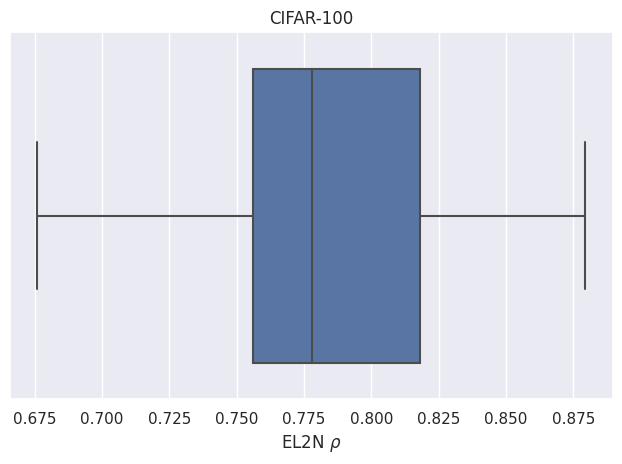

CIFAR-100 selfproto 263
Saving figure to ../outputs/plots/vit/CIFAR-100_selfproto_corr.pdf


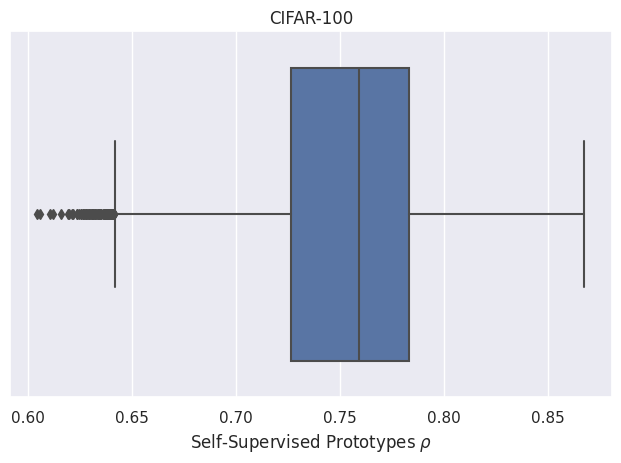

ImageNet el2n 263


  0%|          | 0/263 [00:16<?, ?it/s]


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [23]:
# mean correlations between different classes of models

def compute_model_correlations(sub_df):
    model_attrs = [
        "Model Architecture", "Model Size", "Pretrain Dataset", "Pretrain Samples","global_batch_size", "lr", "warmup"]
    sub_df.sort_values(by=model_attrs)
    corr_df = []
    for i in tqdm(range(len(sub_df))):
        row_a = sub_df.iloc[i]
        score_a = get_score(row_a)
        for  j in range(i+1, len(sub_df)):
            row_b = sub_df.iloc[j]
            score_b = get_score(row_b)
            corr_df.append({
                "Model Index A": i,
                "Model Index B": j,
                **{(k + " A"): row_a[k] for k in model_attrs},
                **{(k + " B"): row_b[k] for k in model_attrs},
                "Correlation": spearmanr(score_a, score_b)[0],
            })
    return pd.DataFrame(corr_df)


df = score_df[score_df["key"].isin({"el2n", "selfproto"}) & (score_df["Training Time"] == "late")]
for (dataset, score_key), sub_df in df.groupby(["Dataset", "key"]):
    print(dataset, score_key, len(sub_df))
    corr_file = FIGURE_ROOT / f"model_corr_late_{dataset}_{score_key}.csv"
    if not corr_file.exists():
        corr_df = compute_model_correlations(sub_df)
        corr_df.to_csv(corr_file)
    corr_df = pd.read_csv(corr_file)

    ax = sns.boxplot(data=corr_df, x="Correlation")
    ax.set_title(dataset)
    ax.set_ylabel("")
    ax.set_xlabel(f"{data_utils.SCORES[score_key]} $\\rho$")
    data_utils.save_fig(FIGURE_ROOT, f"{score_key}_corr", dataset)

# for arch, sub_df in early_late_corr_df.groupby(["Model Architecture"]):

CIFAR-10 el2n 263


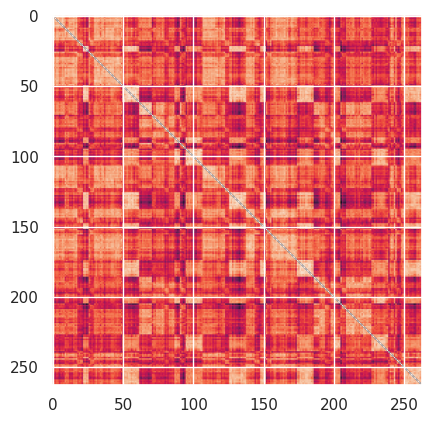

CIFAR-10 selfproto 263


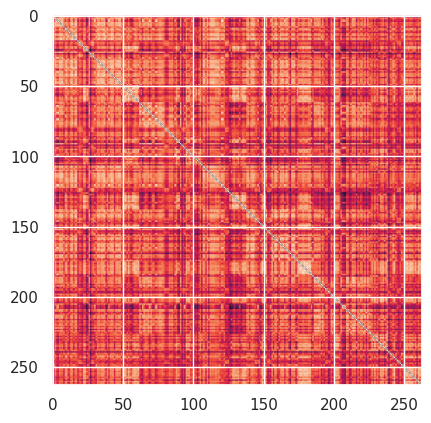

CIFAR-100 el2n 263


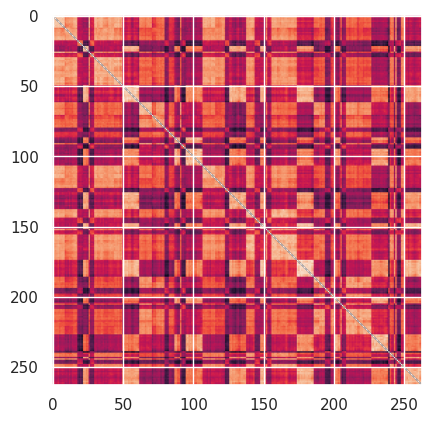

CIFAR-100 selfproto 263


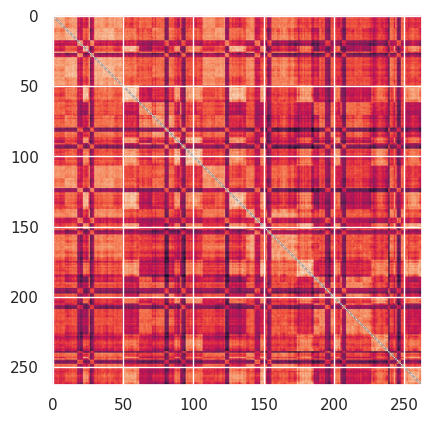

ImageNet el2n 186


  0%|          | 0/186 [00:03<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
df = score_df[score_df["key"].isin({"el2n", "selfproto"}) & (score_df["Training Time"] == "late")]
for (dataset, score_key), sub_df in df.groupby(["Dataset", "key"]):
    print(dataset, score_key, len(sub_df))
    corr_file = FIGURE_ROOT / f"model_corr_late_{dataset}_{score_key}.csv"
    if not corr_file.exists():
        corr_df = compute_model_correlations(sub_df)
        corr_df.to_csv(corr_file)
    corr_df = pd.read_csv(corr_file)
    corr_matrix = corr_matrix_from_df(corr_df, "Model Index A", "Model Index B", corr_row="Correlation", symmetric=True)
    plt.imshow(corr_matrix)
    plt.show()

In [ ]:
# inductive bias: identify clip vs mammut, pretrain dataset, model size

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from scipy.stats import rankdata
from scipy.stats import ttest_ind


def example_pvalues(df):
    models = list(df["Model"].unique())
    new_df = []
    # for every model pair, run a t-test between scores
    for k, sub_df in df.groupby("key"):
        for model_a, model_b in combinations(models, 2):
            score_a = get_scores(data_utils.filter_df(sub_df, {"Model": model_a}))
            score_b = get_scores(data_utils.filter_df(sub_df, {"Model": model_b}))
            test = ttest_ind(score_a, score_b, equal_var=False)
            pvalue = test.pvalue
            # test can return nan if both score_a and score_b are uniformly the same, replace with pvalue=1.0
            pvalue[np.isnan(pvalue)] = 1.0
            new_df.append({
                "Score": sub_df.iloc[0]["Short Name"],
                "Model Pair": (model_a, model_b),
                "P-Value": pvalue,
            })
    new_df = pd.DataFrame(new_df)
    # aggregate t-test p-values using geometric mean
    return new_df


def pvalue_select_examples(df, agg_method=np.min, epsilon=1e-15):
    pval = np.stack(example_pvalues(df)["P-Value"])
    log_pval = -1 * np.log(pval + epsilon)
    log_pval = agg_method(log_pval, axis=0)
    return log_pval


def plot_pca(X, y_true, y_pred=None, name=None, ax=None, title=None, x_label=None, size=None):
    n_components = min(2, X.shape[1], len(set(y_true)) - 1)
    pca = PCA(n_components=n_components)
    pca = pca.fit(X, y_true)
    X_r2 = pca.transform(X)
    x_values = X_r2[:, 0]  if n_components > 1 else X[:, 0]
    y_values = X_r2[:, 1] if n_components > 1 else np.random.uniform(-0.5, 0.5, size=X_r2[:, 0].shape)

    ax = sns.scatterplot(x=x_values, y=y_values, hue=y_true, style=y_pred, size=size, ax=ax)
    ax.set_xlabel("PCA 1" if x_label is None else x_label)
    ax.set_ylabel("PCA 2" if n_components > 1 else "")
    if title is not None:
        ax.set_title(title)
    if n_components > 1:
        ax.set(xticklabels=[])
    else:
        ax.set_ylim(-1, 1)  # make it look like a strip plot
    ax.set(yticklabels=[])

    if title is not None:
        data_utils.save_fig(FIGURE_ROOT, "pca", name=name)
    return pca, ax


def get_features(df, idx=None, avg_over_examples=False, normalize=True, merge_score_dim=True):
    df = df.sort_values(by=["key", "Path"])
    score_order = list(df["key"].unique())
    model_order = list(df["full_name"].unique())

    features = []
    for k, (score_key, sub_df) in zip(score_order, df.groupby("key")):
        # check that scores are in expected order
        assert k == score_key
        # check that every score has same models*runs
        assert np.all(np.stack(sub_df["full_name"]) == model_order)
        score = get_scores(sub_df)  # (models * runs, examples)
        # standardize over each score to make them comparable
        if normalize:
            score = (score - np.mean(score)) / np.std(score)
        # subsample examples
        if idx is not None:
            score = score[:, idx]
        # aggregate over examples
        if avg_over_examples:
            score = np.mean(score, axis=1, keepdims=True)
        features.append(score)

    features = np.stack(features, axis=-1)  # (models * runs, examples, scores)
    if merge_score_dim:
        features = features.reshape(features.shape[0], -1)
    targets = np.stack(sub_df["Model"])

    return features, targets


def aggregate_over_examples_and_scores(coefficients, E, S, agg_method):
    abs_coef = np.abs(coefficients)  # (models, examples*scores)
    M = abs_coef.shape[0]
    abs_coef = abs_coef.reshape(M, E, S)  # (models, examples, scores)
    abs_coef = np.moveaxis(abs_coef, 2, 1).reshape(M * S, E)  # (models * scores, examples)
    # aggregate over models and scores
    coef = agg_method(abs_coef, axis=0)
    return coef


def hardest_select_examples(X, agg_method=np.median):
    R, E, S = X.shape  # (models * runs, examples, scores)
    ranks = rankdata(X, axis=1)
    ranks = ranks.reshape(R, E*S)   # (models * runs, examples * scores)
    ranks = aggregate_over_examples_and_scores(ranks, E, S, agg_method)
    return ranks


def pvalue_select_examples(pval_df, agg_method=np.mean, epsilon=1e-15):
    pval = np.stack(pval_df["P-Value"])
    log_pval = -1 * np.log(pval + epsilon)
    log_pval = agg_method(log_pval, axis=0)
    return log_pval


def top_median_bottom_idx(scores, k):
    idx = np.argsort(scores)
    bottom = idx[:k]
    # put ones closest to median first
    median = idx[np.argsort(np.abs(np.arange(len(scores)) - len(scores) / 2))[:k]]
    # flip so the topmost comes first
    top = np.flip(idx[-k:])
    return top, median, bottom


def fit_logistic(X, y, C=1, penalty="l2"):
    solver = "lbfgs" if penalty == "l2" else "saga"
    classifier = LogisticRegression(penalty=penalty, solver=solver, C=C, max_iter=5e3)
    classifier.fit(X, y)
    return classifier

In [4]:
# inductive bias: pvalue feature selection
# split models into groups via (model architecture, pretrain dataset, model size, global batch size, pretrain samples), create a column "Model" with this group
# run example_pvalues(df) to get scores
# hold out ViT-S-16, relaion2b-en

model_df.groupby(["Model Architecture", "Model Size", "Pretrain Dataset"]).size()
score_df["Model"] = score_df.apply(lambda row: row["Model Architecture"] + " " + row["Model Size"] + " " + row["Pretrain Dataset"], axis=1)

imagenet_df = score_df[(score_df["Dataset"] == "ImageNet") & (score_df["Training Time"] == "late")]
hold_out = (imagenet_df["Model Size"] == "ViT-S-16") | (imagenet_df["Pretrain Dataset"] == "Re-LAION")
train_df = imagenet_df[~hold_out]
held_out_df = imagenet_df[hold_out]

# eval data
imagenet_df = imagenet_df.sort_values(by=["key", "Path"])
IMAGENET_SIZE = 1281167

# hardest
X_train, y_train = get_features(train_df, merge_score_dim=False)
hardest_score = np.median(rankdata(np.mean(X_train, axis=0), axis=0), axis=-1)
hardest_top, hardest_med, hardest_bot = top_median_bottom_idx(hardest_score, 50000)

# pvalue
pval_df = example_pvalues(train_df)
pval_score = pvalue_select_examples(pval_df)
pval_top, pval_med, pval_bot = top_median_bottom_idx(pval_score, 50000)

/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [ ]:
rand_perm = np.random.permutation(IMAGENET_SIZE)

feature_selections = {
    "P-Value (Top)": pval_top,
    "Hardest (Top)": hardest_top,
    "Random": rand_perm,
    "P-Value (Bottom)": pval_bot,
}

model_y = next(iter(imagenet_df.groupby("key")))[1][[
    "Model Architecture",
    "Model Size",
    "Pretrain Dataset",
    "samples_seen",
    "global_batch_size",
    "lr",
    "warmup",
]]
model_y = {k: np.stack(model_y[k]) for k in model_y.columns}


def subset_X(X, idx, n):
    return X[:, idx[:n], :].reshape(X.shape[0], -1)

In [ ]:
from sklearn.model_selection import train_test_split
from itertools import product


X_test, y_test = get_features(held_out_df, merge_score_dim=False)
id_y0, id_y1, id_y2 = list(zip(*[y.split(" ") for y in y_train]))
od_y0, od_y1, od_y2 = list(zip(*[y.split(" ") for y in y_test]))
tasks = [
    ("Architecture", id_y0, od_y0),
    ("Dimensions", id_y1, od_y1),
    ("Pretrain Dataset", id_y2, od_y2),
]
result_df = []
for (feature_selector, idx), n, (task, y_id, y_od) in product(feature_selections.items(), [10, 1000], tasks):
    print(feature_selector, task, n)
    # split the in- and out-distribution data so that the classifier sees all classes
    # use the test set to evaluate accuracy on both in- and out-distribution classes (not used in feature selection)
    X_tr_id, X_te_id, y_tr_id, y_te_id = train_test_split(subset_X(X_train, idx, n), y_train, test_size=0.33, stratify=y_id)
    X_tr_od, X_te_od, y_tr_od, y_te_od = train_test_split(subset_X(X_test, idx, n), y_test, test_size=0.33, stratify=y_od)
    train_X = np.concatenate([X_tr_id, X_tr_od], axis=0)
    train_y = np.concatenate([y_tr_id, y_tr_od], axis=0)
    classifier = fit_logistic(train_X, train_y)
    for dist, X_te, y_te in [("In Distribution", X_te_id, y_te_id), ("Held Out", X_te_od, y_te_od)]:
        y_pred = classifier.predict(X_te)
        result_df.append({
            "Classifier": "Logistic Regression",
            "Feature Selection": feature_selector,
            "Examples": n,
            "Task": task,
            "Distribution": dist,
            "Accuracy": np.sum(y_pred == y_te) / len(y_pred),
        })
result_df = pd.DataFrame(result_df)
result_df.to_csv(FIGURE_ROOT / "feature_select_exp_results.csv")
result_df

P-Value (Top) Architecture 10
P-Value (Top) Dimensions 10
P-Value (Top) Pretrain Dataset 10
P-Value (Top) Architecture 1000
P-Value (Top) Dimensions 1000
P-Value (Top) Pretrain Dataset 1000
Hardest (Top) Architecture 10
Hardest (Top) Dimensions 10
Hardest (Top) Pretrain Dataset 10
Hardest (Top) Architecture 1000
Hardest (Top) Dimensions 1000
Hardest (Top) Pretrain Dataset 1000
Random Architecture 10
Random Dimensions 10
Random Pretrain Dataset 10
Random Architecture 1000
Random Dimensions 1000
Random Pretrain Dataset 1000
P-Value (Bottom) Architecture 10
P-Value (Bottom) Dimensions 10
P-Value (Bottom) Pretrain Dataset 10
P-Value (Bottom) Architecture 1000
P-Value (Bottom) Dimensions 1000
P-Value (Bottom) Pretrain Dataset 1000


,Classifier,Feature Selection,Examples,Task,Distribution,Accuracy
0,Logistic Regression,P-Value (Top),10,Architecture,In Distribution,0.708333
1,Logistic Regression,P-Value (Top),10,Architecture,Held Out,0.800000
2,Logistic Regression,P-Value (Top),10,Dimensions,In Distribution,0.708333
3,Logistic Regression,P-Value (Top),10,Dimensions,Held Out,0.600000
4,Logistic Regression,P-Value (Top),10,Pretrain Dataset,In Distribution,0.770833
5,Logistic Regression,P-Value (Top),10,Pretrain Dataset,Held Out,0.775000
6,Logistic Regression,P-Value (Top),1000,Architecture,In Distribution,0.958333
7,Logistic Regression,P-Value (Top),1000,Architecture,Held Out,0.850000
8,Logistic Regression,P-Value (Top),1000,Dimensions,In Distribution,0.958333
9,Logistic Regression,P-Value (Top),1000,Dimensions,Held Out,0.950000


<AxesSubplot:xlabel='Examples', ylabel='Accuracy'>

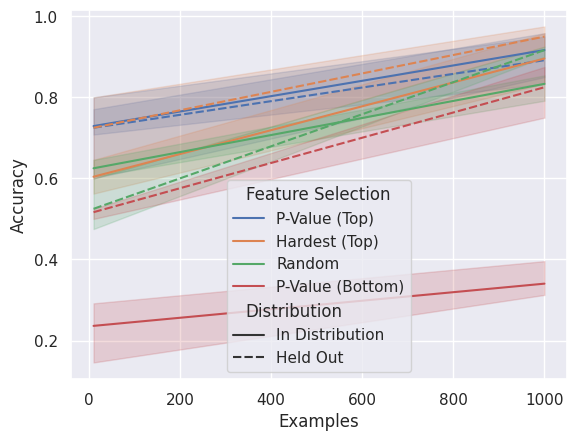

In [ ]:
sns.lineplot(data=result_df, x="Examples", y="Accuracy", hue="Feature Selection", style="Distribution")

Hardest (Top) 2
Saving figure to ../outputs/plots/vit/Hardest_Top_2_pca.pdf


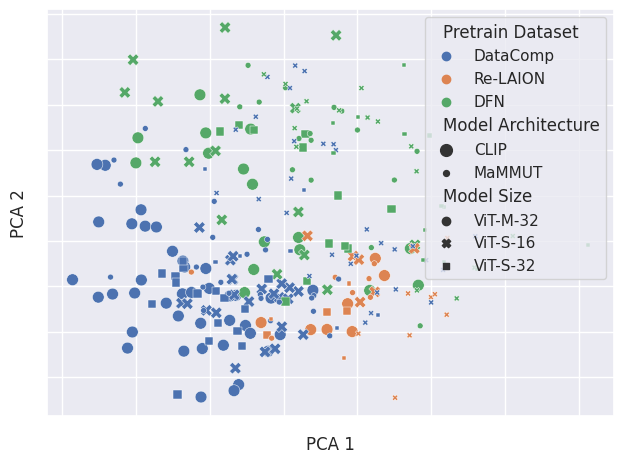

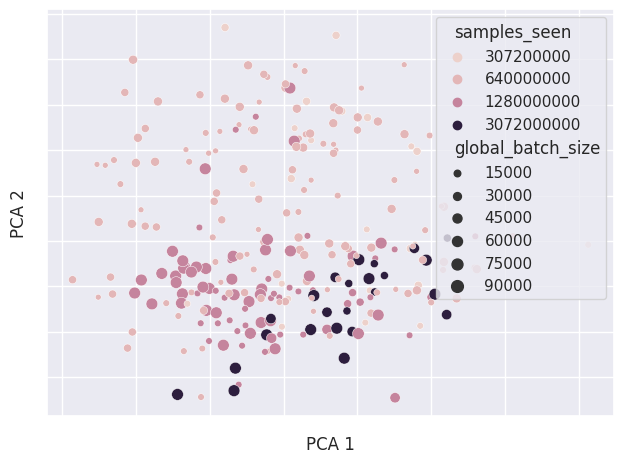

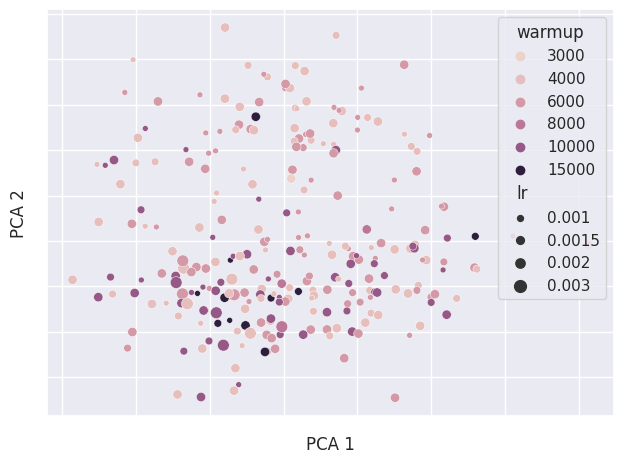

P-Value (Top) 2
Saving figure to ../outputs/plots/vit/P-Value_Top_2_pca.pdf


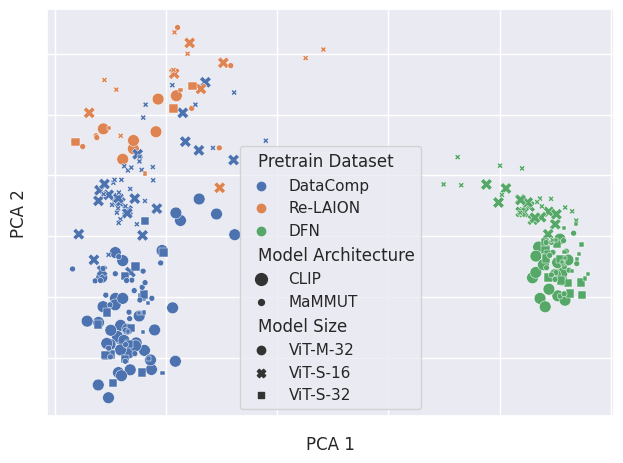

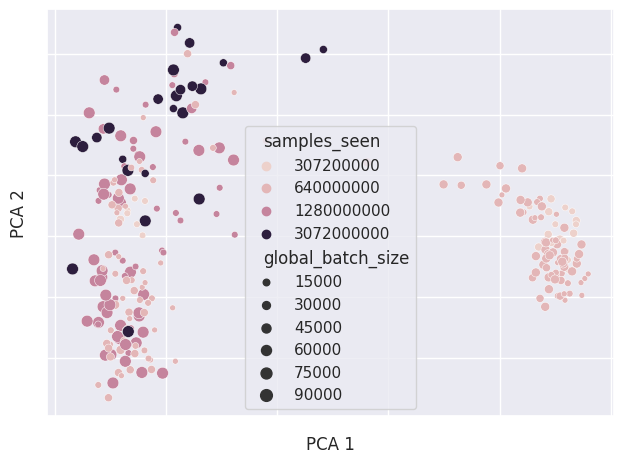

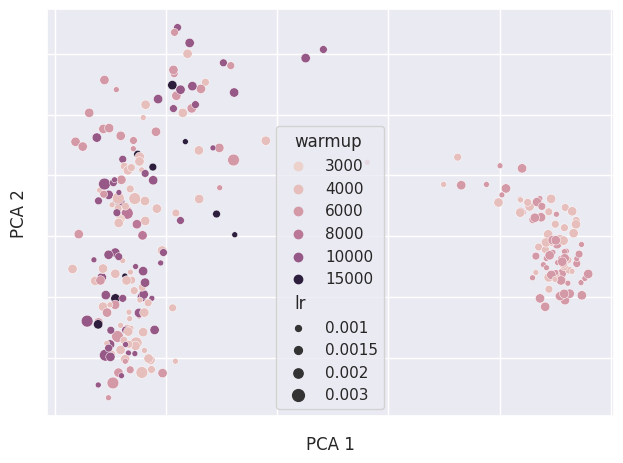

P-Value (Median) 2
Saving figure to ../outputs/plots/vit/P-Value_Median_2_pca.pdf


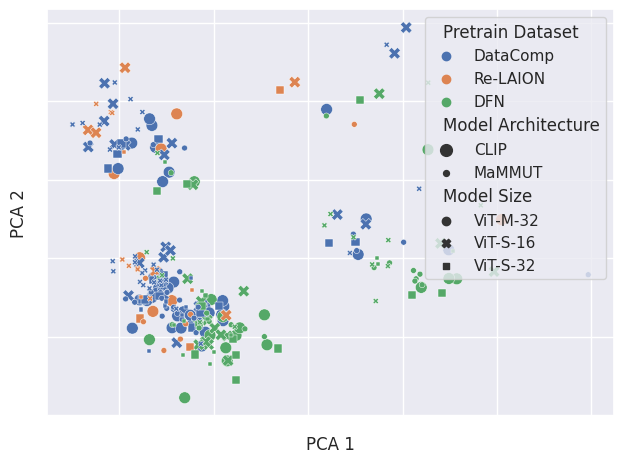

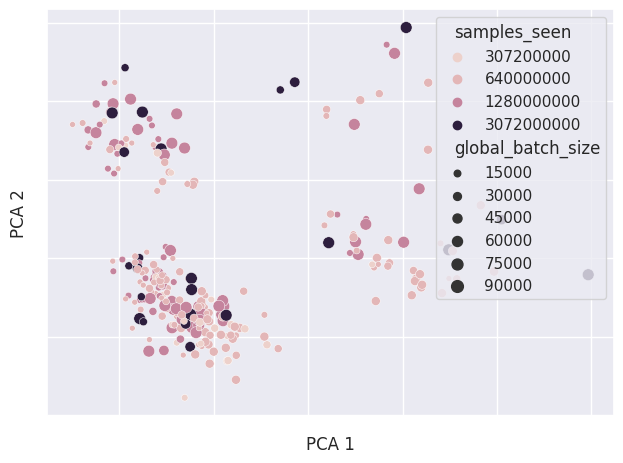

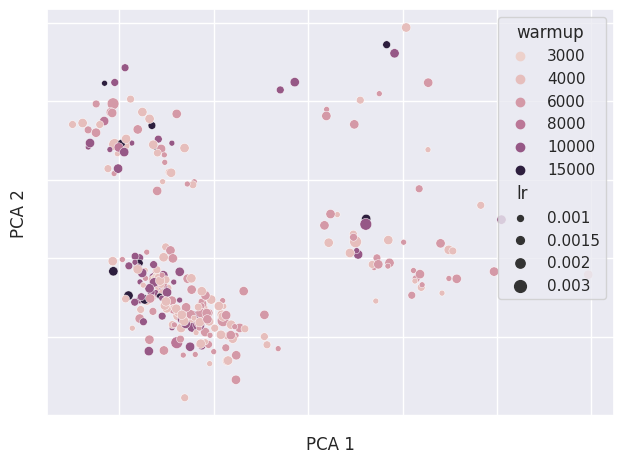

P-Value (Bottom) 2
Saving figure to ../outputs/plots/vit/P-Value_Bottom_2_pca.pdf


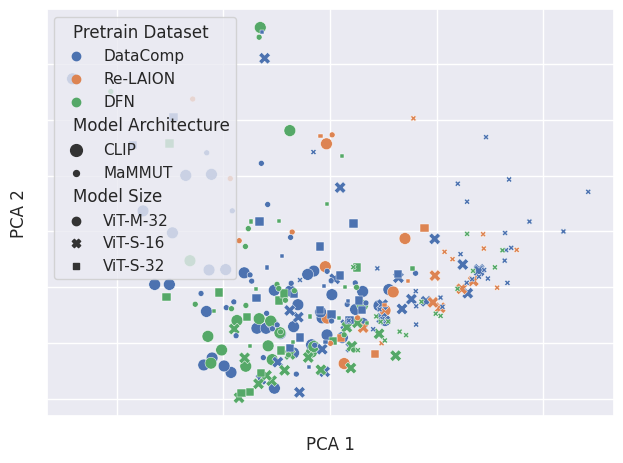

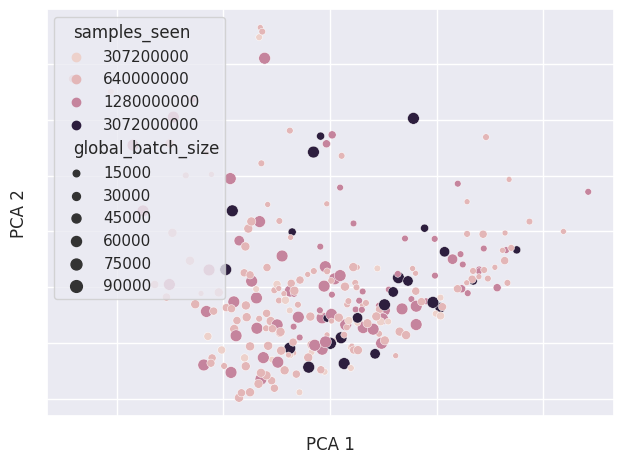

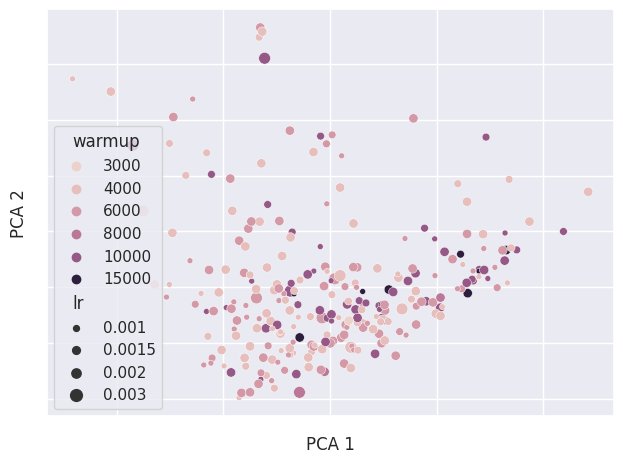

Random 2
Saving figure to ../outputs/plots/vit/Random_2_pca.pdf


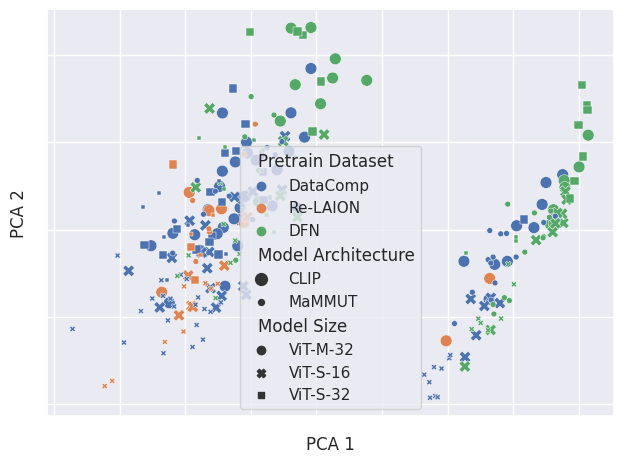

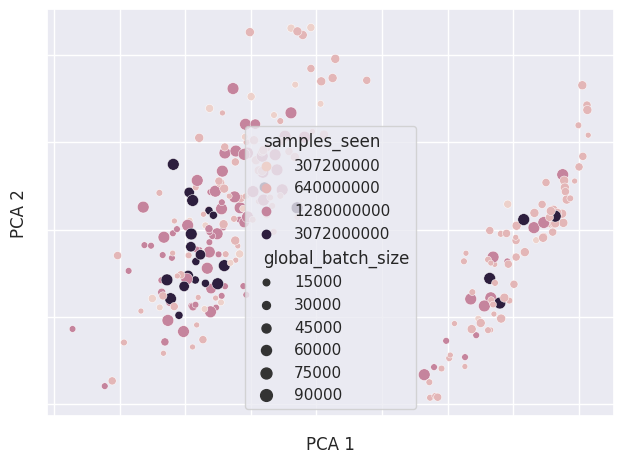

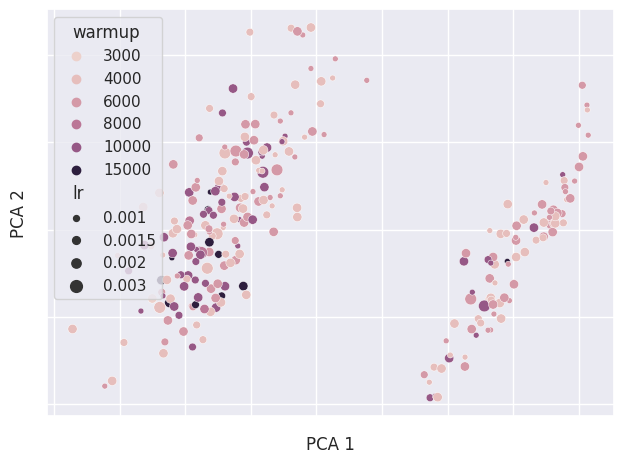

<Figure size 640x480 with 0 Axes>

In [65]:
feature_selections = {
    "Hardest (Top)": hardest_top,
    "P-Value (Top)": pval_top,
    "P-Value (Median)": pval_med,
    "P-Value (Bottom)": pval_bot,
    "Random": rand_perm,
}

# X_all, y_all = get_features(imagenet_df, merge_score_dim=False)
for feature_selector, idx in feature_selections.items():
    print(feature_selector, n)
    X_all_subset = subset_X(X_all, idx, 2)
    plot_pca(X_all_subset, model_y["Pretrain Dataset"], model_y["Model Size"], size=model_y["Model Architecture"])
    data_utils.save_fig(FIGURE_ROOT, "pca", name=f"{feature_selector} {n}")
    plot_pca(X_all_subset, model_y["samples_seen"], size=model_y["global_batch_size"])
    data_utils.save_fig(FIGURE_ROOT, "pca")
    plot_pca(X_all_subset, model_y["warmup"], size=model_y["lr"])
    data_utils.save_fig(FIGURE_ROOT, "pca")
